<a href="https://colab.research.google.com/github/b181005/Cellpose-Image-Analysis/blob/main/cellposeAll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# set up


### 1. Configuration — Define Experiment Variables

In [217]:
dir_path = "/content/drive/MyDrive/DATA/Chris/HM 11-03-26"

vehicle = 'B+'
drug = 'S+B+'
expression_control = 'CH1'
experiment_output = 'CH4'


### 2. Installation — Install Required Python Packages

In [218]:
%pip install cellpose matplotlib numpy imagecodecs --quiet

### 3. Imports — Load Libraries & Verify GPU Access

In [219]:
 #single image plot test
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

2026-03-31 19:48:11,474 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 19:48:11,475 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 19:48:11,475 [INFO] ** TORCH CUDA version installed and working. **


# Google Drive

### 4. Google Drive — Mount Drive & List Directories

In [220]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
!ls /content/drive/MyDrive/DATA/

Mounted at /content/drive
Chris  Himanshu  Isak  Joan  Josh  Kaden  Mari	Shreedevi


### 5. File Discovery — Locate & List TIFF Image Files

In [221]:
# 1. Define path with a default fallback
try:
    dir_path = dir_path
except NameError:
    dir_path = "/content/drive/MyDrive/DATA/images/Psychatg02_07112025"

dir_obj = Path(dir_path)

if not dir_obj.exists():
    raise FileNotFoundError(f"Directory not found: {dir_path}")

# 2. List the files
image_ext = ".tif"
all_files = list(dir_obj.rglob("*" + image_ext))
files = natsorted([f for f in all_files if "_masks" not in f.name and "_flows" not in f.name])

# 3. Check if files were found
if len(files) == 0:
    print(f"Warning: No {image_ext} files found in {dir_path}")
else:
    print(f"{len(files)} images found.")
    print(f"Success! Found {len(files)} total images across all subfolders.")
    # Show the first 3 paths to verify they are correct
    for f in files[:3]:
        print(f"Found: {f}")

74 images found.
Success! Found 74 total images across all subfolders.
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_CH1.tif
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_CH4.tif
Found: /content/drive/MyDrive/DATA/Chris/HM 11-03-26/oprm/test 1/B+_M+_w1/W001/P00001/B+M+_W001_P00001_Overlay.tif


### 6. Core Analysis Function — Define `run_cell_analysis()`

In [222]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from cellpose import models, plot, io, core
import pandas as pd
import seaborn as sns
import os
import imagecodecs
from pathlib import Path
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime to one with GPU")

def run_cell_analysis(image_path, condition_label, primary_channel_tag, secondary_channel_tag):
    """
    Performs feature extraction using existing masks if available,
    otherwise runs Cellpose segmentation.
    """
    print(f"--- Analyzing: {os.path.basename(image_path)} ---")
    global rows
    global primary_id

    p = Path(image_path)
    # Construct path for the secondary channel image based on primary_channel_tag and secondary_channel_tag
    secondary_channel_path = p.with_name(p.name.replace(f"_{primary_channel_tag}.tif", f"_{secondary_channel_tag}.tif"))
    mask_path = p.with_name(p.stem + "_masks.tif")

    if not secondary_channel_path.exists():
        print(f"Skipping: Secondary channel ({secondary_channel_tag}) pair not found for {p.name}")
        return

    # Load Images
    primary_img = io.imread(str(p))
    secondary_img = io.imread(str(secondary_channel_path))

    # Check for existing masks
    if mask_path.exists():
        print(f"Using existing mask: {mask_path.name}")
        masks = io.imread(str(mask_path))
    else:
        print("No mask found. Running Cellpose segmentation...")
        # Run Cellpose, using the primary image for segmentation
        masks_output, flows, styles = model.eval([primary_img], diameter=30, channels=[0,0])
        masks = masks_output[0]

    # Measure Properties
    props_primary = regionprops(masks, intensity_image=primary_img)
    props_secondary = regionprops(masks, intensity_image=secondary_img)

    file_name = p.stem

    for p_primary, p_secondary in zip(props_primary, props_secondary):
        rows.append({
            "file": file_name,
            "condition": condition_label,
            "cell_id": p_primary.label,
            "area_px": p_primary.area,
            f"mean_{primary_channel_tag.lower()}": p_primary.mean_intensity, # Dynamic key
            f"mean_{secondary_channel_tag.lower()}": p_secondary.mean_intensity # Dynamic key
        })
    primary_id += 1

2026-03-31 19:48:12,698 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 19:48:12,699 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 19:48:12,699 [INFO] ** TORCH CUDA version installed and working. **


### 7. Analysis Loop — Sort Files by Treatment & Run Cell Analysis

In [223]:
# 1. Define your treatment keywords
vehicle = 'B+'
drug = 'S+B+'
expression_control = 'CH1'
experiment_output = 'CH4'

# 2. Define the mapping by Treatment group first
# We check for Drug before Vehicle to handle the 'B+' overlap
study_keys = ['Drug', 'Veh']
study_map = {
    'Drug': drug,
    'Veh':  vehicle
}

# 3. Initialize dictionary
separated_files = {key: [] for key in study_map.keys()}

# 4. Sort files into Treatment groups
for file_path in dir_obj.rglob('*.tif'):
    if '_masks' in file_path.name or '_flows' in file_path.name:
        continue

    path_str = str(file_path)
    # Check for Drug first
    if drug in path_str:
        separated_files['Drug'].append(file_path)
    elif vehicle in path_str:
        separated_files['Veh'].append(file_path)

# 5. Updated Analysis Loop to handle both channels within each treatment
rows = []
primary_id = 1 # Initialize primary_id here

for treatment, file_list in separated_files.items():
    print(f"\nProcessing Treatment Group: {treatment}")
    # Find all CH2 files in this treatment group
    ch2_files = [f for f in file_list if expression_control in f.name]

    for ch2_p in ch2_files:
        # Determine if this specific folder/file represents a Control or Exp condition
        # (You can customize this logic if 'Exp' vs 'Ctrl' is determined by folder names)
        condition_label = f"{treatment}_Analyzed"
        run_cell_analysis(str(ch2_p), condition_label, expression_control, experiment_output)

# 6. Create DataFrame
df_combined = pd.DataFrame(rows)
print(f"\nTotal cells analyzed: {len(df_combined)}")


Processing Treatment Group: Drug

Processing Treatment Group: Veh
--- Analyzing: B+M++_W001_P00001_CH1.tif ---
Using existing mask: B+M++_W001_P00001_CH1_masks.tif
--- Analyzing: B+M++_W001_P00003_CH1.tif ---
Using existing mask: B+M++_W001_P00003_CH1_masks.tif
--- Analyzing: B+M++_W001_P00002_CH1.tif ---
Using existing mask: B+M++_W001_P00002_CH1_masks.tif
--- Analyzing: B+M++_W001_P00006_CH1.tif ---
Using existing mask: B+M++_W001_P00006_CH1_masks.tif
--- Analyzing: B+M++_W001_P00005_CH1.tif ---
Using existing mask: B+M++_W001_P00005_CH1_masks.tif
--- Analyzing: B+M++_W001_P00004_CH1.tif ---
Using existing mask: B+M++_W001_P00004_CH1_masks.tif
--- Analyzing: B+_W001_P00003_CH1.tif ---
Using existing mask: B+_W001_P00003_CH1_masks.tif
--- Analyzing: B+_W001_P00006_CH1.tif ---
Using existing mask: B+_W001_P00006_CH1_masks.tif
--- Analyzing: B+_W001_P00002_CH1.tif ---
Using existing mask: B+_W001_P00002_CH1_masks.tif
--- Analyzing: B+_W001_P00004_CH1.tif ---
Using existing mask: B+_W00

### 8. Supplemental Import — imagecodecs

In [224]:
import imagecodecs

### 9. Re-run Analysis Loop (Alternative Version)

In [225]:
# 2. Define the mapping by Treatment group first
# We check for Drug before Vehicle to handle the 'B+' overlap
study_keys = ['Drug', 'Veh']
study_map = {
    'Drug': drug,
    'Veh':  vehicle
}

# 3. Initialize dictionary
separated_files = {key: [] for key in study_map.keys()}

# 4. Sort files into Treatment groups
for file_path in dir_obj.rglob('*.tif'):
    if '_masks' in file_path.name or '_flows' in file_path.name:
        continue

    path_str = str(file_path)
    # Check for Drug first
    if drug in path_str:
        separated_files['Drug'].append(file_path)
    elif vehicle in path_str:
        separated_files['Veh'].append(file_path)

# 5. Updated Analysis Loop to handle both channels within each treatment
rows = []

for treatment, file_list in separated_files.items():
    print(f"\nProcessing Treatment Group: {treatment}")
    # Find all CH2 files in this treatment group
    ch2_files = [f for f in file_list if expression_control in f.name]

    for ch2_p in ch2_files:
        # Determine if this specific folder/file represents a Control or Exp condition
        # (You can customize this logic if 'Exp' vs 'Ctrl' is determined by folder names)
        condition_label = f"{treatment}_Analyzed"
        run_cell_analysis(str(ch2_p), condition_label, expression_control, experiment_output)

# 6. Create DataFrame
df_combined = pd.DataFrame(rows)
print(f"\nTotal cells analyzed: {len(df_combined)}")


Processing Treatment Group: Drug

Processing Treatment Group: Veh
--- Analyzing: B+M++_W001_P00001_CH1.tif ---
Using existing mask: B+M++_W001_P00001_CH1_masks.tif
--- Analyzing: B+M++_W001_P00003_CH1.tif ---
Using existing mask: B+M++_W001_P00003_CH1_masks.tif
--- Analyzing: B+M++_W001_P00002_CH1.tif ---
Using existing mask: B+M++_W001_P00002_CH1_masks.tif
--- Analyzing: B+M++_W001_P00006_CH1.tif ---
Using existing mask: B+M++_W001_P00006_CH1_masks.tif
--- Analyzing: B+M++_W001_P00005_CH1.tif ---
Using existing mask: B+M++_W001_P00005_CH1_masks.tif
--- Analyzing: B+M++_W001_P00004_CH1.tif ---
Using existing mask: B+M++_W001_P00004_CH1_masks.tif
--- Analyzing: B+_W001_P00003_CH1.tif ---
Using existing mask: B+_W001_P00003_CH1_masks.tif
--- Analyzing: B+_W001_P00006_CH1.tif ---
Using existing mask: B+_W001_P00006_CH1_masks.tif
--- Analyzing: B+_W001_P00002_CH1.tif ---
Using existing mask: B+_W001_P00002_CH1_masks.tif
--- Analyzing: B+_W001_P00004_CH1.tif ---
Using existing mask: B+_W00

### 10. Model Initialization & Analysis Run with Ratio Calculation

In [226]:
from cellpose import models, io, core
import pandas as pd
import numpy as np
import os
from pathlib import Path

# 1. Initialize the Cellpose model
model = models.CellposeModel(gpu=True)

# 2. Initialize data storage
rows = []
primary_id = 1

# 3. Define the cleanup helper inside the loop cell to ensure it is used
def get_scalar(val):
    # If it is an array/list (like [R, G, B]), take the max or a specific channel
    if isinstance(val, (list, np.ndarray)) and len(np.atleast_1d(val)) > 1:
        return np.max(val)
    return val

# The global variables expression_control and experiment_output are defined in the new config cell
# They are assumed to be available from previous execution.

# 4. Loop through every condition
for condition, file_list in separated_files.items():
    print(f"\nProcessing group: {condition}")
    # Filter files for the primary channel tag
    ch2_files = [f for f in file_list if f"_{expression_control}.tif" in f.name]

    for file_path in ch2_files:
        # Call run_cell_analysis with the new channel parameters
        run_cell_analysis(str(file_path), condition, expression_control, experiment_output)

# 5. Create and clean the DataFrame
df_combined = pd.DataFrame(rows)

if not df_combined.empty:
    # Apply scalar conversion to the intensity columns, using dynamic names
    df_combined[f'mean_{expression_control.lower()}'] = df_combined[f'mean_{expression_control.lower()}'].apply(get_scalar)
    df_combined[f'mean_{experiment_output.lower()}'] = df_combined[f'mean_{experiment_output.lower()}'].apply(get_scalar)

    # Recalculate ratio using dynamic names
    df_combined['ratio_647_gfp'] = df_combined[f'mean_{experiment_output.lower()}'] / (df_combined[f'mean_{expression_control.lower()}'] + 1e-9)

    print(f"\nDone! Total cells analyzed: {len(df_combined)}")
    display(df_combined.head())
else:
    print("No data collected.")

2026-03-31 19:48:14,517 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 19:48:14,517 [INFO] >>>> using GPU (CUDA)
2026-03-31 19:48:15,159 [INFO] >>>> loading model /root/.cellpose/models/cpsam

Processing group: Drug

Processing group: Veh
--- Analyzing: B+M++_W001_P00001_CH1.tif ---
Using existing mask: B+M++_W001_P00001_CH1_masks.tif
--- Analyzing: B+M++_W001_P00003_CH1.tif ---
Using existing mask: B+M++_W001_P00003_CH1_masks.tif
--- Analyzing: B+M++_W001_P00002_CH1.tif ---
Using existing mask: B+M++_W001_P00002_CH1_masks.tif
--- Analyzing: B+M++_W001_P00006_CH1.tif ---
Using existing mask: B+M++_W001_P00006_CH1_masks.tif
--- Analyzing: B+M++_W001_P00005_CH1.tif ---
Using existing mask: B+M++_W001_P00005_CH1_masks.tif
--- Analyzing: B+M++_W001_P00004_CH1.tif ---
Using existing mask: B+M++_W001_P00004_CH1_masks.tif
--- Analyzing: B+_W001_P00003_CH1.tif ---
Using existing mask: B+_W001_P00003_CH1_masks.tif
--- Analyzing: B+_W001_P00006_CH1.tif ---
Using existing mask:

,file,condition,cell_id,area_px,mean_ch1,mean_ch4,ratio_647_gfp
0,B+M++_W001_P00001_CH1,Veh,1,86.0,13.767442,8.825581,0.641047
1,B+M++_W001_P00001_CH1,Veh,2,204.0,20.225490,22.063725,1.090887
2,B+M++_W001_P00001_CH1,Veh,3,42.0,24.642857,30.928571,1.255072
3,B+M++_W001_P00001_CH1,Veh,4,201.0,11.159204,8.159204,0.731164
4,B+M++_W001_P00001_CH1,Veh,5,133.0,17.518797,11.390977,0.650215


### 11. Mask Generation — Generate & Save Cellpose Masks

In [227]:
import tifffile
from cellpose import io
import numpy as np

def save_missing_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        # Use the global expression_control variable
        ch2_files = [f for f in file_list if f'_{expression_control}.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask: {mask_path.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists: {mask_path.name}')

save_missing_masks(separated_files, model)

Mask already exists: B+M++_W001_P00001_CH1_masks.tif
Mask already exists: B+M++_W001_P00003_CH1_masks.tif
Mask already exists: B+M++_W001_P00002_CH1_masks.tif
Mask already exists: B+M++_W001_P00006_CH1_masks.tif
Mask already exists: B+M++_W001_P00005_CH1_masks.tif
Mask already exists: B+M++_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00003_CH1_masks.tif
Mask already exists: B+_W001_P00006_CH1_masks.tif
Mask already exists: B+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists: B+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00004_CH1_masks.tif
Mask already exists: B+M+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00005_CH1_masks.tif
Mask already exists: B+M+_W001_P00006_CH1_masks.tif
Mask already exists: B+M+_W001_P00003_CH1_masks.tif
Mask already exists: B+M+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists:

### 12. Segmentation Preview — Visualize Masks on Primary Channel

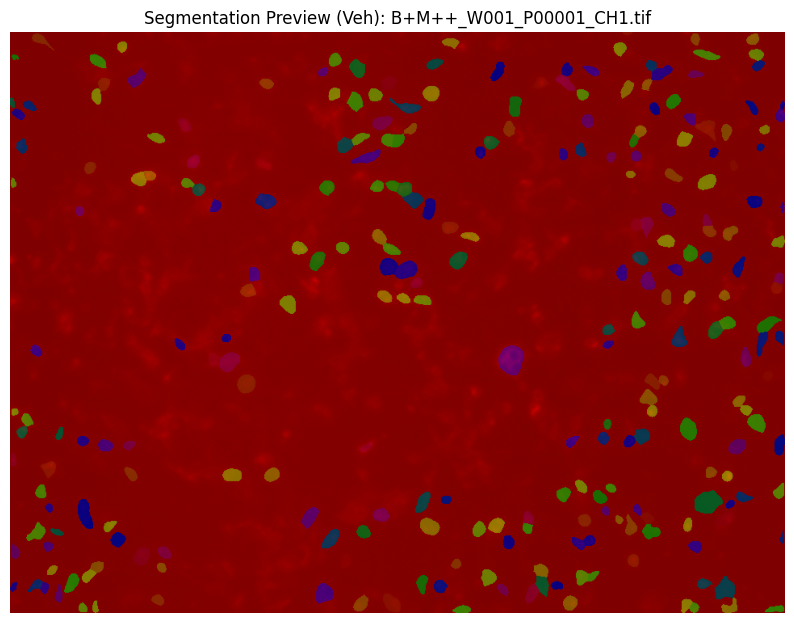

In [228]:
# Segmentation Preview
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

# Updated to use 'Veh_Ctrl' instead of 'Control'
preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

### 13. Channel Intensity Preview — Inspect CH4 Images

File: B+M++_W001_P00001_CH4.tif
Shape: (720, 960, 3)
Max Intensity: 251
Min Intensity: 0


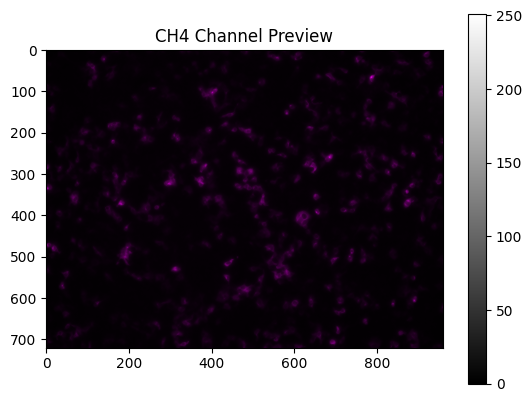

In [229]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
# Assuming 'Veh' is the new 'Control' or a similar group for preview
if 'separated_files' in locals() and 'Veh' in separated_files:
    test_file_list = separated_files['Veh']
    ch4_test_file = None
    for f in test_file_list:
        # Look for a file that corresponds to the experiment_output channel
        if f'_{experiment_output}.tif' in f.name:
            ch4_test_file = f
            break

    if ch4_test_file:
        ch4_img_test = io.imread(str(ch4_test_file))
        print(f"File: {ch4_test_file.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title(f'{experiment_output} Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"No {experiment_output} file found in 'Veh' group for preview.")
else:
    print("Group 'Veh' not found in separated_files.")

### 14. Mask Generation — Save Missing Masks (Retry)

In [230]:
import tifffile
from cellpose import io
import numpy as np

def save_missing_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        # Use the global expression_control variable
        ch2_files = [f for f in file_list if f'_{expression_control}.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask: {mask_path.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists: {mask_path.name}')

save_missing_masks(separated_files, model)

Mask already exists: B+M++_W001_P00001_CH1_masks.tif
Mask already exists: B+M++_W001_P00003_CH1_masks.tif
Mask already exists: B+M++_W001_P00002_CH1_masks.tif
Mask already exists: B+M++_W001_P00006_CH1_masks.tif
Mask already exists: B+M++_W001_P00005_CH1_masks.tif
Mask already exists: B+M++_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00003_CH1_masks.tif
Mask already exists: B+_W001_P00006_CH1_masks.tif
Mask already exists: B+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists: B+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00004_CH1_masks.tif
Mask already exists: B+M+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00005_CH1_masks.tif
Mask already exists: B+M+_W001_P00006_CH1_masks.tif
Mask already exists: B+M+_W001_P00003_CH1_masks.tif
Mask already exists: B+M+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists:

### 15. Segmentation Preview (Retry)

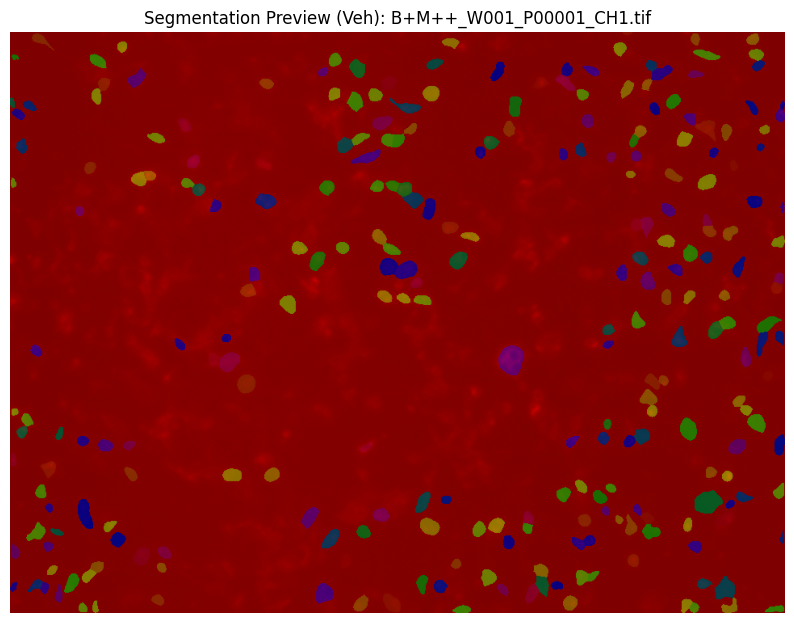

In [231]:
# Segmentation Preview
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

# Updated to use 'Veh_Ctrl' instead of 'Control'
preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

### 16. Channel Intensity Preview — CH4 (Retry)

File: B+M++_W001_P00001_CH4.tif
Shape: (720, 960, 3)
Max Intensity: 251
Min Intensity: 0


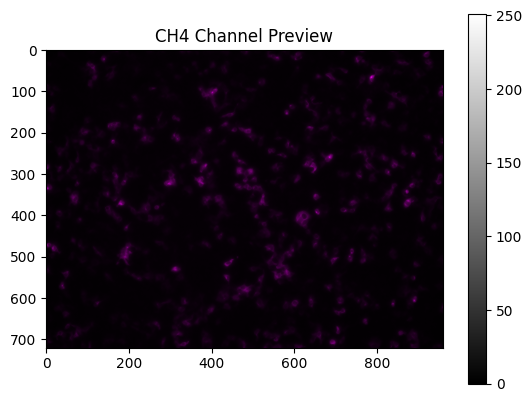

In [232]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
# Assuming 'Veh' is the new 'Control' or a similar group for preview
if 'separated_files' in locals() and 'Veh' in separated_files:
    test_file_list = separated_files['Veh']
    ch4_test_file = None
    for f in test_file_list:
        # Look for a file that corresponds to the experiment_output channel
        if f'_{experiment_output}.tif' in f.name:
            ch4_test_file = f
            break

    if ch4_test_file:
        ch4_img_test = io.imread(str(ch4_test_file))
        print(f"File: {ch4_test_file.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title(f'{experiment_output} Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"No {experiment_output} file found in 'Veh' group for preview.")
else:
    print("Group 'Veh' not found in separated_files.")

### 17. Channel Intensity Preview — CH4 (Duplicate)

File: B+M++_W001_P00001_CH4.tif
Shape: (720, 960, 3)
Max Intensity: 251
Min Intensity: 0


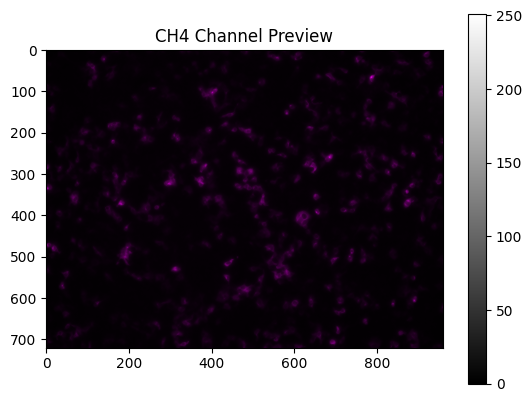

In [233]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
# Assuming 'Veh' is the new 'Control' or a similar group for preview
if 'separated_files' in locals() and 'Veh' in separated_files:
    test_file_list = separated_files['Veh']
    ch4_test_file = None
    for f in test_file_list:
        # Look for a file that corresponds to the experiment_output channel
        if f'_{experiment_output}.tif' in f.name:
            ch4_test_file = f
            break

    if ch4_test_file:
        ch4_img_test = io.imread(str(ch4_test_file))
        print(f"File: {ch4_test_file.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title(f'{experiment_output} Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"No {experiment_output} file found in 'Veh' group for preview.")
else:
    print("Group 'Veh' not found in separated_files.")

### 18. Mask Generation (Duplicate)

In [234]:
import tifffile
from cellpose import io
import numpy as np

def save_missing_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        # Use the global expression_control variable
        ch2_files = [f for f in file_list if f'_{expression_control}.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask: {mask_path.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists: {mask_path.name}')

save_missing_masks(separated_files, model)

Mask already exists: B+M++_W001_P00001_CH1_masks.tif
Mask already exists: B+M++_W001_P00003_CH1_masks.tif
Mask already exists: B+M++_W001_P00002_CH1_masks.tif
Mask already exists: B+M++_W001_P00006_CH1_masks.tif
Mask already exists: B+M++_W001_P00005_CH1_masks.tif
Mask already exists: B+M++_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00003_CH1_masks.tif
Mask already exists: B+_W001_P00006_CH1_masks.tif
Mask already exists: B+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists: B+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00004_CH1_masks.tif
Mask already exists: B+M+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00005_CH1_masks.tif
Mask already exists: B+M+_W001_P00006_CH1_masks.tif
Mask already exists: B+M+_W001_P00003_CH1_masks.tif
Mask already exists: B+M+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists:

### 19. Segmentation Preview (Duplicate)

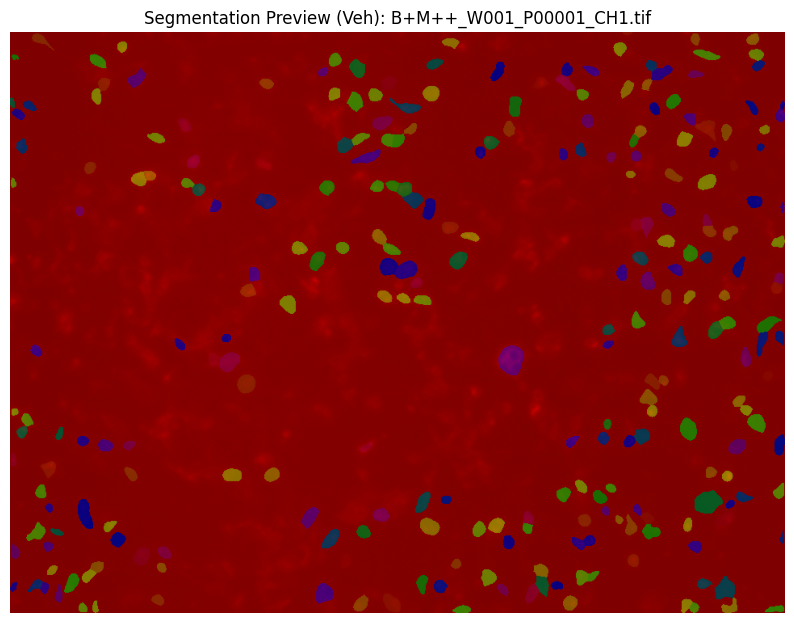

In [235]:
# Segmentation Preview
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

# Updated to use 'Veh_Ctrl' instead of 'Control'
preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

### 20. Channel Intensity Preview — CH4 (Duplicate)

File: B+M++_W001_P00001_CH4.tif
Shape: (720, 960, 3)
Max Intensity: 251
Min Intensity: 0


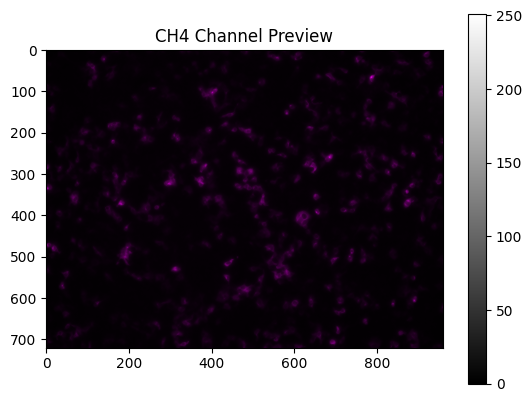

In [236]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
# Assuming 'Veh' is the new 'Control' or a similar group for preview
if 'separated_files' in locals() and 'Veh' in separated_files:
    test_file_list = separated_files['Veh']
    ch4_test_file = None
    for f in test_file_list:
        # Look for a file that corresponds to the experiment_output channel
        if f'_{experiment_output}.tif' in f.name:
            ch4_test_file = f
            break

    if ch4_test_file:
        ch4_img_test = io.imread(str(ch4_test_file))
        print(f"File: {ch4_test_file.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title(f'{experiment_output} Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"No {experiment_output} file found in 'Veh' group for preview.")
else:
    print("Group 'Veh' not found in separated_files.")

### 21. Model Init & Full Analysis Run (Duplicate)

In [237]:
from cellpose import models, io, core
import pandas as pd
import numpy as np
import os
from pathlib import Path

# 1. Initialize the Cellpose model
model = models.CellposeModel(gpu=True)

# 2. Initialize data storage
rows = []
primary_id = 1

# 3. Define the cleanup helper inside the loop cell to ensure it is used
def get_scalar(val):
    # If it is an array/list (like [R, G, B]), take the max or a specific channel
    if isinstance(val, (list, np.ndarray)) and len(np.atleast_1d(val)) > 1:
        return np.max(val)
    return val

# 4. Loop through every condition
for condition, file_list in separated_files.items():
    print(f"\nProcessing group: {condition}")
    ch2_files = [f for f in file_list if f"_{expression_control}.tif" in f.name]

    for file_path in ch2_files:
        run_cell_analysis(str(file_path), condition, expression_control, experiment_output)

# 5. Create and clean the DataFrame
df_combined = pd.DataFrame(rows)

if not df_combined.empty:
    # Apply scalar conversion to the intensity columns, using dynamic names
    df_combined[f'mean_{expression_control.lower()}'] = df_combined[f'mean_{expression_control.lower()}'].apply(get_scalar)
    df_combined[f'mean_{experiment_output.lower()}'] = df_combined[f'mean_{experiment_output.lower()}'].apply(get_scalar)

    # Recalculate ratio using dynamic names
    df_combined['ratio_647_gfp'] = df_combined[f'mean_{experiment_output.lower()}'] / (df_combined[f'mean_{expression_control.lower()}'] + 1e-9)

    print(f"\nDone! Total cells analyzed: {len(df_combined)}")
    display(df_combined.head())
else:
    print("No data collected.")

2026-03-31 19:48:17,134 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 19:48:17,135 [INFO] >>>> using GPU (CUDA)
2026-03-31 19:48:17,778 [INFO] >>>> loading model /root/.cellpose/models/cpsam

Processing group: Drug

Processing group: Veh
--- Analyzing: B+M++_W001_P00001_CH1.tif ---
Using existing mask: B+M++_W001_P00001_CH1_masks.tif
--- Analyzing: B+M++_W001_P00003_CH1.tif ---
Using existing mask: B+M++_W001_P00003_CH1_masks.tif
--- Analyzing: B+M++_W001_P00002_CH1.tif ---
Using existing mask: B+M++_W001_P00002_CH1_masks.tif
--- Analyzing: B+M++_W001_P00006_CH1.tif ---
Using existing mask: B+M++_W001_P00006_CH1_masks.tif
--- Analyzing: B+M++_W001_P00005_CH1.tif ---
Using existing mask: B+M++_W001_P00005_CH1_masks.tif
--- Analyzing: B+M++_W001_P00004_CH1.tif ---
Using existing mask: B+M++_W001_P00004_CH1_masks.tif
--- Analyzing: B+_W001_P00003_CH1.tif ---
Using existing mask: B+_W001_P00003_CH1_masks.tif
--- Analyzing: B+_W001_P00006_CH1.tif ---
Using existing mask:

,file,condition,cell_id,area_px,mean_ch1,mean_ch4,ratio_647_gfp
0,B+M++_W001_P00001_CH1,Veh,1,86.0,13.767442,8.825581,0.641047
1,B+M++_W001_P00001_CH1,Veh,2,204.0,20.225490,22.063725,1.090887
2,B+M++_W001_P00001_CH1,Veh,3,42.0,24.642857,30.928571,1.255072
3,B+M++_W001_P00001_CH1,Veh,4,201.0,11.159204,8.159204,0.731164
4,B+M++_W001_P00001_CH1,Veh,5,133.0,17.518797,11.390977,0.650215


### 22. Quick DataFrame Snapshot

In [238]:
df = pd.DataFrame(rows)
df

,file,condition,cell_id,area_px,mean_ch1,mean_ch4
0,B+M++_W001_P00001_CH1,Veh,1,86.0,"[13.767441860465116, 0.0, 0.0]","[8.825581395348838, 0.0, 8.825581395348838]"
1,B+M++_W001_P00001_CH1,Veh,2,204.0,"[20.225490196078432, 0.0, 0.0]","[22.063725490196077, 0.0, 22.063725490196077]"
2,B+M++_W001_P00001_CH1,Veh,3,42.0,"[24.642857142857142, 0.0, 0.0]","[30.928571428571427, 0.0, 30.928571428571427]"
3,B+M++_W001_P00001_CH1,Veh,4,201.0,"[11.159203980099502, 0.0, 0.0]","[8.159203980099502, 0.0, 8.159203980099502]"
4,B+M++_W001_P00001_CH1,Veh,5,133.0,"[17.518796992481203, 0.0, 0.0]","[11.390977443609023, 0.0, 11.390977443609023]"
...,...,...,...,...,...,...
5727,B+_W001_P00002_CH1,Veh,123,215.0,"[51.72558139534884, 0.0, 0.0]","[40.74418604651163, 0.0, 40.74418604651163]"
5728,B+_W001_P00002_CH1,Veh,124,184.0,"[60.71739130434783, 0.0, 0.0]","[25.83695652173913, 0.0, 25.83695652173913]"
5729,B+_W001_P00002_CH1,Veh,125,199.0,"[56.768844221105525, 0.0, 0.0]","[22.934673366834172, 0.0, 22.934673366834172]"
5730,B+_W001_P00002_CH1,Veh,126,170.0,"[21.88235294117647, 0.0, 0.0]","[7.235294117647059, 0.0, 7.235294117647059]"


### 23. Group Separation — Split Drug vs Vehicle DataFrames

In [239]:
# Separate the combined data using the analyzed treatment labels
df_veh = df_combined[df_combined['condition'] == 'Veh_Analyzed'].copy()
df_drug = df_combined[df_combined['condition'] == 'Drug_Analyzed'].copy()

print(f"Vehicle group cells: {len(df_veh)}")
print(f"Drug group cells: {len(df_drug)}")

Vehicle group cells: 0
Drug group cells: 0


### 24. Visualization — Violin Plot: Signal Ratio by Condition

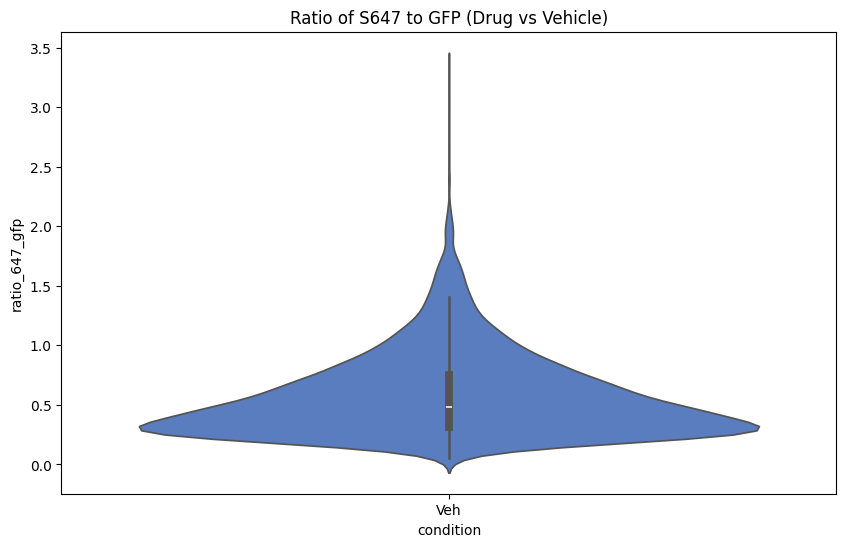

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_combined,
    x='condition',
    y='ratio_647_gfp',
    hue='condition',
    legend=False,
    palette='muted'
)
plt.title('Ratio of S647 to GFP (Drug vs Vehicle)')
plt.show()

### 25. Mask Generation — Save All Masks Function

In [241]:
import tifffile

def save_all_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        ch2_files = [f for f in file_list if f'_{expression_control}.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask for: {p.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists for: {p.name}')

save_all_masks(separated_files, model)

Mask already exists for: B+M++_W001_P00001_CH1.tif
Mask already exists for: B+M++_W001_P00003_CH1.tif
Mask already exists for: B+M++_W001_P00002_CH1.tif
Mask already exists for: B+M++_W001_P00006_CH1.tif
Mask already exists for: B+M++_W001_P00005_CH1.tif
Mask already exists for: B+M++_W001_P00004_CH1.tif
Mask already exists for: B+_W001_P00003_CH1.tif
Mask already exists for: B+_W001_P00006_CH1.tif
Mask already exists for: B+_W001_P00002_CH1.tif
Mask already exists for: B+_W001_P00004_CH1.tif
Mask already exists for: B+_W001_P00005_CH1.tif
Mask already exists for: B+_W001_P00001_CH1.tif
Mask already exists for: B+M+_W001_P00004_CH1.tif
Mask already exists for: B+M+_W001_P00001_CH1.tif
Mask already exists for: B+M+_W001_P00005_CH1.tif
Mask already exists for: B+M+_W001_P00006_CH1.tif
Mask already exists for: B+M+_W001_P00003_CH1.tif
Mask already exists for: B+M+_W001_P00002_CH1.tif
Mask already exists for: B+_W001_P00005_CH1.tif
Mask already exists for: B+_W001_P00001_CH1.tif
Mask alrea

### 26. Mask Generation — Save Missing Masks (Final)

In [242]:
import tifffile
from cellpose import io
import numpy as np

def save_missing_masks(separated_files, model):
    for condition, file_list in separated_files.items():
        ch2_files = [f for f in file_list if f'_{expression_control}.tif' in f.name]
        for p in ch2_files:
            mask_path = p.with_name(p.stem + '_masks.tif')
            if not mask_path.exists():
                print(f'Generating and saving mask: {mask_path.name}')
                img = io.imread(str(p))
                masks_output, flows, styles = model.eval([img], diameter=30, channels=[0,0])
                masks = masks_output[0]
                tifffile.imwrite(str(mask_path), masks.astype(np.uint16))
            else:
                print(f'Mask already exists: {mask_path.name}')

save_missing_masks(separated_files, model)

Mask already exists: B+M++_W001_P00001_CH1_masks.tif
Mask already exists: B+M++_W001_P00003_CH1_masks.tif
Mask already exists: B+M++_W001_P00002_CH1_masks.tif
Mask already exists: B+M++_W001_P00006_CH1_masks.tif
Mask already exists: B+M++_W001_P00005_CH1_masks.tif
Mask already exists: B+M++_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00003_CH1_masks.tif
Mask already exists: B+_W001_P00006_CH1_masks.tif
Mask already exists: B+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00004_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists: B+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00004_CH1_masks.tif
Mask already exists: B+M+_W001_P00001_CH1_masks.tif
Mask already exists: B+M+_W001_P00005_CH1_masks.tif
Mask already exists: B+M+_W001_P00006_CH1_masks.tif
Mask already exists: B+M+_W001_P00003_CH1_masks.tif
Mask already exists: B+M+_W001_P00002_CH1_masks.tif
Mask already exists: B+_W001_P00005_CH1_masks.tif
Mask already exists:

### 27. Data Review — Display Combined DataFrame

In [243]:
df_combined

,file,condition,cell_id,area_px,mean_ch1,mean_ch4,ratio_647_gfp
0,B+M++_W001_P00001_CH1,Veh,1,86.0,13.767442,8.825581,0.641047
1,B+M++_W001_P00001_CH1,Veh,2,204.0,20.225490,22.063725,1.090887
2,B+M++_W001_P00001_CH1,Veh,3,42.0,24.642857,30.928571,1.255072
3,B+M++_W001_P00001_CH1,Veh,4,201.0,11.159204,8.159204,0.731164
4,B+M++_W001_P00001_CH1,Veh,5,133.0,17.518797,11.390977,0.650215
...,...,...,...,...,...,...,...
5727,B+_W001_P00002_CH1,Veh,123,215.0,51.725581,40.744186,0.787699
5728,B+_W001_P00002_CH1,Veh,124,184.0,60.717391,25.836957,0.425528
5729,B+_W001_P00002_CH1,Veh,125,199.0,56.768844,22.934673,0.404001
5730,B+_W001_P00002_CH1,Veh,126,170.0,21.882353,7.235294,0.330645


### 28. Visualization — Scatter Plot: CH1 vs CH4 Intensity per Cell

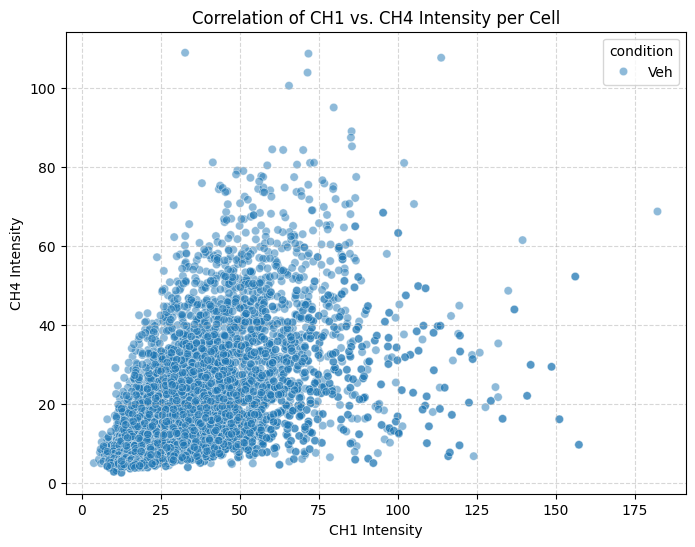

In [249]:
col_x = f'mean_{expression_control.lower()}'
col_y = f'mean_{experiment_output.lower()}'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_combined,
    x=col_x,
    y=col_y,
    hue='condition',
    alpha=0.5
)
plt.xlabel(f"{expression_control} Intensity")
plt.ylabel(f"{experiment_output} Intensity")
plt.title(f"Correlation of {expression_control} vs. {experiment_output} Intensity per Cell")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 29. Segmentation Preview — Overlay Masks on Image

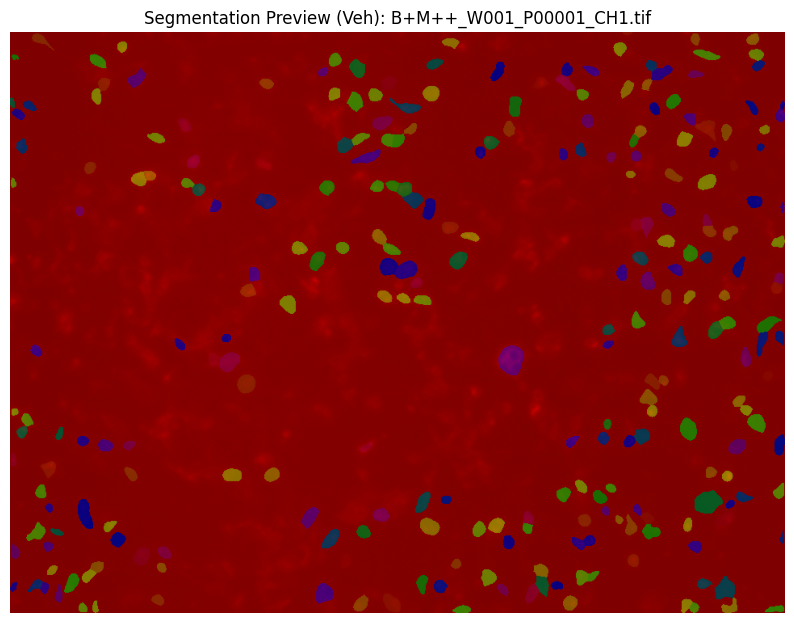

In [245]:
from cellpose import io, plot
import matplotlib.pyplot as plt
from pathlib import Path

# Updated to use 'Veh_Ctrl' instead of 'Control'
preview_group = 'Veh'

if 'separated_files' in locals() and preview_group in separated_files:
    ch2_files = [f for f in separated_files[preview_group] if f'_{expression_control}.tif' in f.name]
    if ch2_files:
        test_file = ch2_files[0]
        img = io.imread(str(test_file))
        mask_path = test_file.with_name(test_file.stem + '_masks.tif')

        if mask_path.exists():
            masks = io.imread(str(mask_path))
            plt.figure(figsize=(10, 8))
            plt.imshow(img, cmap='gray')
            plt.imshow(masks, alpha=0.5, cmap='prism')
            plt.title(f'Segmentation Preview ({preview_group}): {test_file.name}')
            plt.axis('off')
            plt.show()
        else:
            print(f'Mask file not found at: {mask_path}')
else:
    print(f'Group {preview_group} not found in separated_files.')

### 30. Channel Intensity Preview — CH4 File Check (Legacy Version)

File: B+M++_W001_P00001_Overlay.tif
Shape: (720, 960, 3)
Max Intensity: 252
Min Intensity: 0


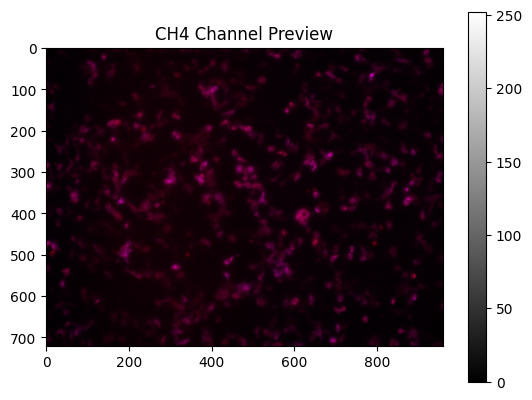

In [246]:
import matplotlib.pyplot as plt

# Let's check the first CH4 file found in the 'Control' group
if 'separated_files' in locals() and separated_files['Veh']:
    test_file = separated_files['Veh'][0]
    # Construct CH4 path like the analysis function does
    ch4_test_path = test_file.with_name(test_file.name.replace('_CH2.tif', '_CH4.tif'))

    if ch4_test_path.exists():
        ch4_img_test = io.imread(str(ch4_test_path))
        print(f"File: {ch4_test_path.name}")
        print(f"Shape: {ch4_img_test.shape}")
        print(f"Max Intensity: {ch4_img_test.max()}")
        print(f"Min Intensity: {ch4_img_test.min()}")

        plt.imshow(ch4_img_test, cmap='gray')
        plt.title('CH4 Channel Preview')
        plt.colorbar()
        plt.show()
    else:
        print(f"CH4 file not found at: {ch4_test_path}")

# Save Plots for AI


### 31. Export Options — Save Figures as Vector Files (Commented Out)

In [247]:
# import matplotlib.pyplot as plt

# plt.plot([1, 2, 3], [4, 5, 6])
# plt.savefig("figure.svg")   # SVG vector
# plt.savefig("figure.pdf")   # PDF vector
# plt.savefig("figure.eps")   # EPS vector


### 32. Dimensionality Reduction — PCA of Cell Features

In [248]:
from sklearn.decomposition import PCA
import seaborn as sns

# Prepare numeric data for PCA
numeric_cols = ['area_px', 'mean_gfp', 'mean_s647', 'ratio_647_gfp']
# Ensure we only use rows that have all numeric data
pca_data = df_combined.dropna(subset=numeric_cols)

if not pca_data.empty:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(pca_data[numeric_cols])

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=X_pca[:,0],
        y=X_pca[:,1],
        hue=pca_data['condition'],
        alpha=0.6,
        palette=['blue', 'gray']
    )
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    plt.title("PCA of Cell Features (Area and Intensities)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
else:
    print('Insufficient data for PCA.')

KeyError: ['mean_gfp', 'mean_s647']

### 33. PCA (Empty Cell / Continuation)